# Week 6 Assignment - Autoencoder for Image Denoising

Building an autoencoder that removes noise from MNIST digit images.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

np.random.seed(42)
tf.random.set_seed(42)

## 2. Load and Preprocess the MNIST Dataset

Using the MNIST dataset directly from keras.datasets since it is the same data as the Kaggle dataset linked in the assignment. Pixel values are scaled to 0-1 and reshaped to add the channel dimension needed for Conv2D layers.

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

# normalize pixel values between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# reshape to (samples, 28, 28, 1) for conv layers
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape, x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1) (10000, 28, 28, 1)


## 3. Add Noise to the Images

Adding Gaussian noise to create the noisy versions of the images. The autoencoder will be trained to map these noisy images back to the clean originals.

In [3]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# clip values so they stay in valid pixel range after adding noise
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

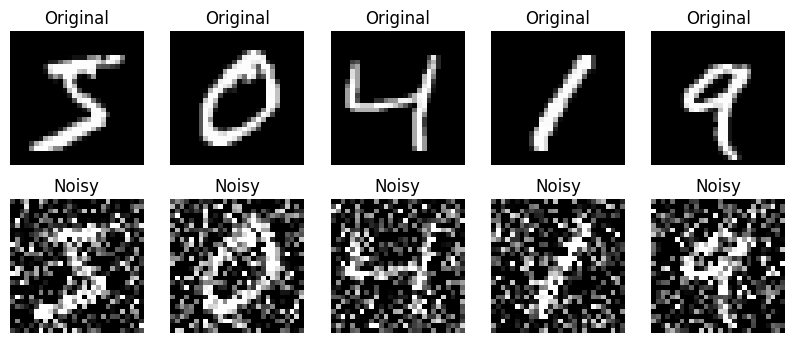

In [4]:
# quick check of what the noisy images look like compared to clean ones
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
plt.show()

## 4. Build the Autoencoder Model

The encoder compresses the noisy 28x28 image down using conv + maxpooling layers, and the decoder upsamples it back to the original size, ideally reconstructing the clean digit in the process.

In [5]:
input_img = Input(shape=(28, 28, 1))

# encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# decoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

Training the autoencoder with the noisy images as input and the clean images as the target output.

In [6]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 293ms/step - loss: 0.1634 - val_loss: 0.1150
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 289ms/step - loss: 0.1120 - val_loss: 0.1076
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 291ms/step - loss: 0.1069 - val_loss: 0.1043
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 295ms/step - loss: 0.1044 - val_loss: 0.1025
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 292ms/step - loss: 0.1027 - val_loss: 0.1011
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 284ms/step - loss: 0.1014 - val_loss: 0.0999
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 287ms/step - loss: 0.1002 - val_loss: 0.0988
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 135s 287ms/step - loss: 0.0993 - val_loss: 0.0983
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 297ms/step - loss: 0.0986 - val_loss: 0.0977
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 286ms/step - loss: 0.0980 - val_loss: 0.0972
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 149s 301ms/step - loss: 0.0975 - val_loss: 0.0967
Epoch 12

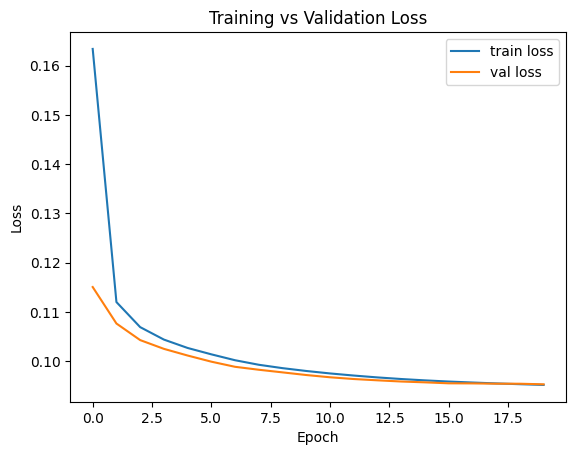

In [7]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## 6. Denoise Test Images and Visualize Results

Passing the noisy test images through the trained autoencoder and comparing the original, noisy, and denoised versions side by side.

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


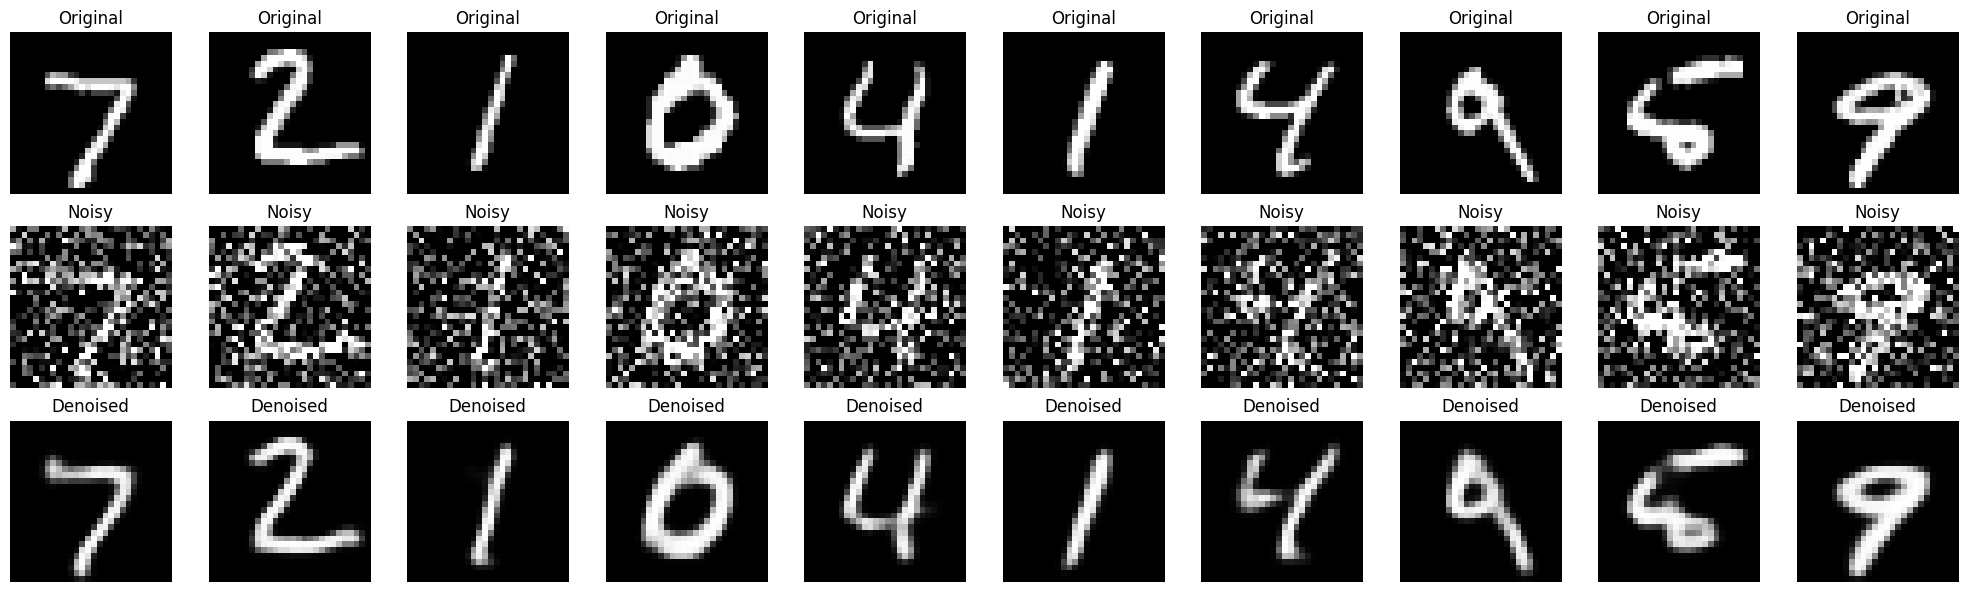

In [8]:
denoised_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 7. Evaluate Model Performance

In [9]:
test_loss = autoencoder.evaluate(x_test_noisy, x_test)
print("Test loss (binary crossentropy):", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0953
Test loss (binary crossentropy): 0.09529642760753632


## Observations

- The autoencoder learns to reconstruct clean digits from noisy inputs by compressing the image into a smaller encoded representation and then rebuilding it back to the original size.
- Since the model is trained on noisy-to-clean pairs, it learns to ignore the random noise pattern and focus on the actual digit structure.
- Loss keeps decreasing across epochs and the denoised outputs are visibly much cleaner than the noisy inputs, close to the original digits.
- Increasing the noise_factor makes the denoising task harder, and using more conv layers or filters could improve reconstruction quality further.